<h1><center>Time Series Stationarity + Forecasting (with ETS + Weather)<center><h1>


In [9]:
# prompts used in the tests
"""
1- "Give me a step-by-step plan to analyze smart meter data for stationarity and ETS forecasting at different granularities."

2- "How can I test stationarity for hourly, daily, weekly, and monthly energy consumption using ADF and annotated plots?"

3- "Can I use weather variables like temperature as exogenous features in ETS models?"

"""

'\n1- "Give me a step-by-step plan to analyze smart meter data for stationarity and ETS forecasting at different granularities."\n\n2- "How can I test stationarity for hourly, daily, weekly, and monthly energy consumption using ADF and annotated plots?"\n\n3- "Can I use weather variables like temperature as exogenous features in ETS models?"\n\n'

## Objective

This notebook explores stationarity and forecasting using ETS models for energy consumption data at different aggregation levels (hourly, daily, weekly, monthly). Weather data is also incorporated to reveal additional insights.

### Goals:

- Evaluate stationarity at multiple granularities
- Forecast using ETS models
- Annotate plots clearly
- Compare levels of precision
- Integrate weather for richer insights


In [ ]:
# import necessary libraries
# data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from calendar import month_name
import matplotlib.dates as mdates

# Load all relevant data
block = pd.read_csv('block_21.csv')
weather = pd.read_csv('weather_hourly_darksky.csv')


In [2]:
# melt to long format
# add timestamp
half_hour_cols = [f"hh_{i}" for i in range(48)]
df_long = block.melt(id_vars=["LCLid", "day"], value_vars=half_hour_cols,
                     var_name="half_hour", value_name="energy_kwh")

df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='min')
df_long = df_long.dropna(subset=['energy_kwh'])
df_long.set_index('timestamp', inplace=True)


In [3]:
#create new time series with different time intervals
ts_hourly = df_long['energy_kwh'].resample('H').mean()
ts_daily = df_long['energy_kwh'].resample('D').mean()
ts_weekly = df_long['energy_kwh'].resample('W').mean()
ts_monthly = df_long['energy_kwh'].resample('M').mean()


/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_8636/3197953446.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_hourly = df_long['energy_kwh'].resample('H').mean()
/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_8636/3197953446.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_monthly = df_long['energy_kwh'].resample('M').mean()


ADF Statistic for Hourly: -5.165
p-value: 0.000
Stationary


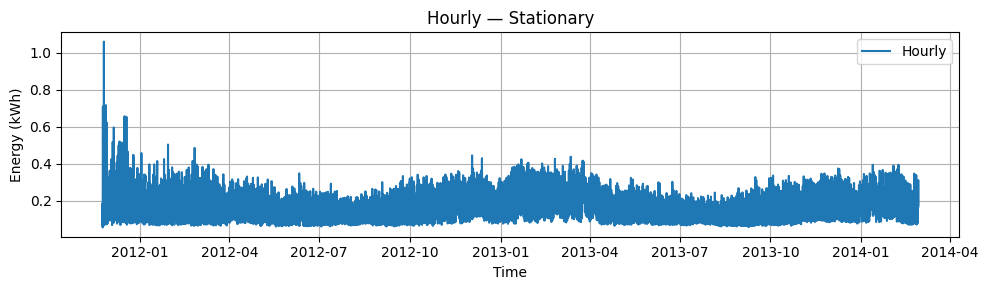

ADF Statistic for Daily: -2.458
p-value: 0.126
Not stationary


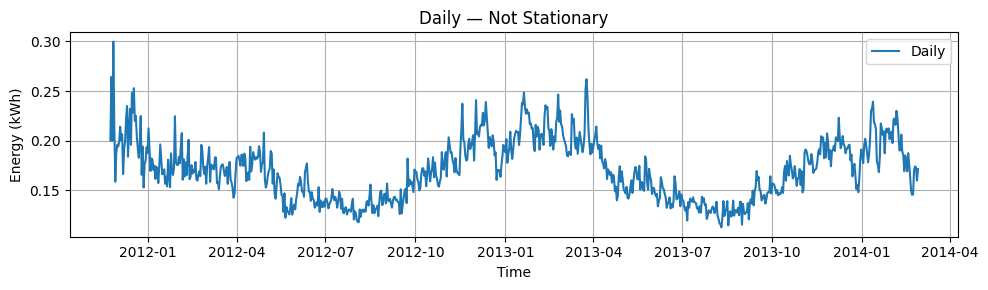

ADF Statistic for Weekly: -3.596
p-value: 0.006
Stationary


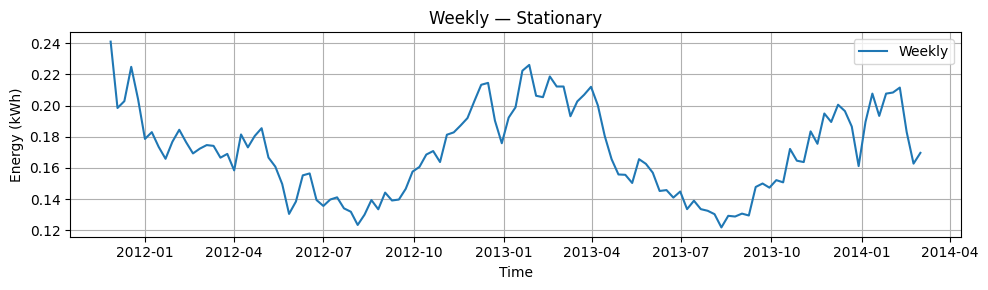

ADF Statistic for Monthly: -4.626
p-value: 0.000
Stationary


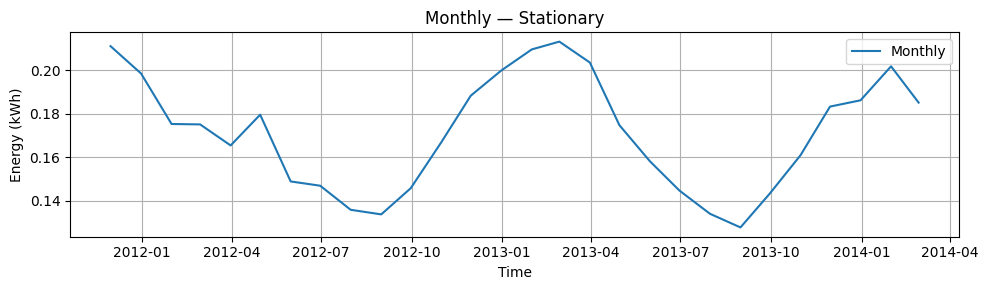

In [4]:
#stationarity test with ADF test and plot
def test_stationarity(series, title):
    result = adfuller(series.dropna())
    print(f"ADF Statistic for {title}: {result[0]:.3f}")
    print(f"p-value: {result[1]:.3f}")
    print("Stationary" if result[1] < 0.05 else "Not stationary")

    plt.figure(figsize=(10, 3))
    plt.plot(series, label=title)
    plt.title(f"{title} — {'Stationary' if result[1] < 0.05 else 'Not Stationary'}")
    plt.xlabel("Time")
    plt.ylabel("Energy (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# Test stationarity for different time series
test_stationarity(ts_hourly, "Hourly")
test_stationarity(ts_daily, "Daily")
test_stationarity(ts_weekly, "Weekly")
test_stationarity(ts_monthly, "Monthly")


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.63433D+00    |proj g|=  5.25519D+00

At iterate    1    f= -2.68088D+00    |proj g|=  7.72149D+00

At iterate    2    f= -2.72785D+00    |proj g|=  4.26570D+00

At iterate    3    f= -2.76049D+00    |proj g|=  8.92608D-01

At iterate    4    f= -2.76870D+00    |proj g|=  8.88307D-01

At iterate    5    f= -2.79733D+00    |proj g|=  1.98674D+00

At iterate    6    f= -2.85213D+00    |proj g|=  1.93184D+00

At iterate    7    f= -2.91155D+00    |proj g|=  8.41070D+00

At iterate    8    f= -2.93607D+00    |proj g|=  9.37334D-01

At iterate    9    f= -2.94422D+00    |proj g|=  4.93482D+00

At iterate   10    f= -2.95475D+00    |proj g|=  1.10641D+01

At iterate   11    f= -2.96555D+00    |proj g|=  4.11564D+00

At iterate   12    f= -2.96767D+00    |proj g|=  1.58257D+00

At iterate   13    f= -2.9

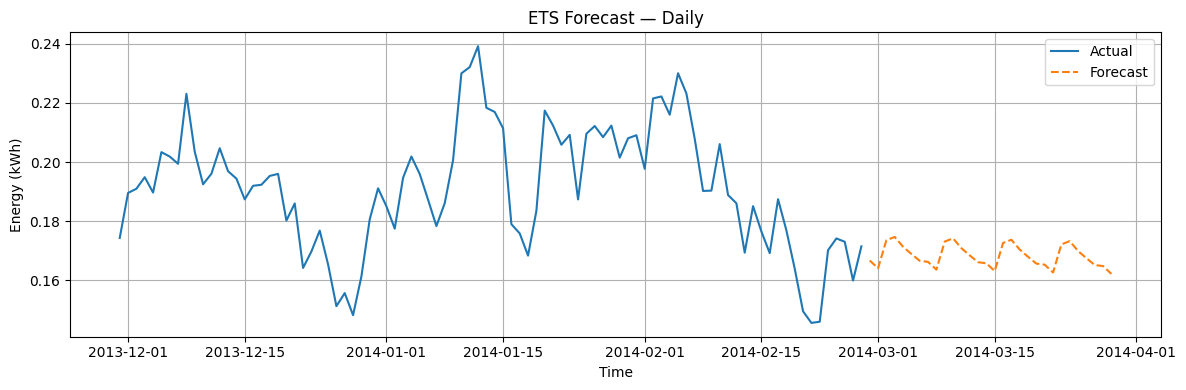

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           56     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.54988D+00    |proj g|=  4.39507D+00

At iterate    1    f= -1.56858D+00    |proj g|=  3.03543D+00

At iterate    2    f= -2.21190D+00    |proj g|=  7.21695D+00

At iterate    3    f= -2.71398D+00    |proj g|=  7.87422D+00

At iterate    4    f= -3.03526D+00    |proj g|=  9.37579D+00

At iterate    5    f= -3.11135D+00    |proj g|=  2.46663D+00

At iterate    6    f= -3.15322D+00    |proj g|=  3.79741D+00

At iterate    7    f= -3.16876D+00    |proj g|=  8.69135D-01

At iterate    8    f= -3.18572D+00    |proj g|=  1.29025D+00

At iterate    9    f= -3.20190D+00    |proj g|=  1.89855D+00

At iterate   10    f= -3.21789D+00    |proj g|=  2.45204D+00

At iterate   11    f= -3.22395D+00    |proj g|=  7.14490D-01

At iterate   12    f= -3.22655D+00    |proj g|=  2.14112D-01

At iterate   13    f= -3.2

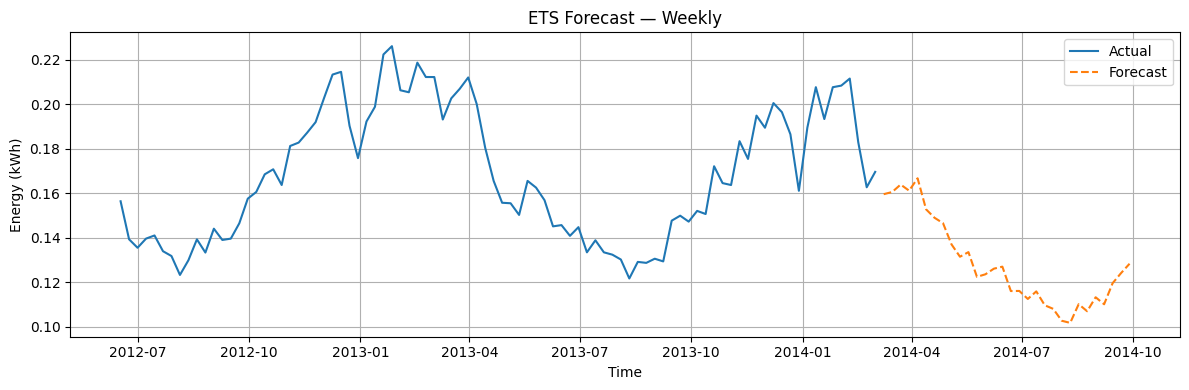

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.49411D+00    |proj g|=  1.32422D+01

At iterate    1    f= -1.51518D+00    |proj g|=  2.56916D+00

At iterate    2    f= -2.40389D+00    |proj g|=  1.17760D+02

At iterate    3    f= -2.44100D+00    |proj g|=  5.13176D+01

At iterate    4    f= -2.56399D+00    |proj g|=  3.09625D+01

At iterate    5    f= -2.58349D+00    |proj g|=  9.21606D+00

At iterate    6    f= -2.60744D+00    |proj g|=  7.55896D+00

At iterate    7    f= -2.64832D+00    |proj g|=  1.03760D+01

At iterate    8    f= -2.73588D+00    |proj g|=  2.27974D+01

At iterate    9    f= -2.78705D+00    |proj g|=  1.39126D+01

At iterate   10    f= -2.82399D+00    |proj g|=  1.71546D+01

At iterate   11    f= -2.83948D+00    |proj g|=  1.00313D+01

At iterate   12    f= -2.86404D+00    |proj g|=  1.97691D+01

At iterate   13    f= -2.8

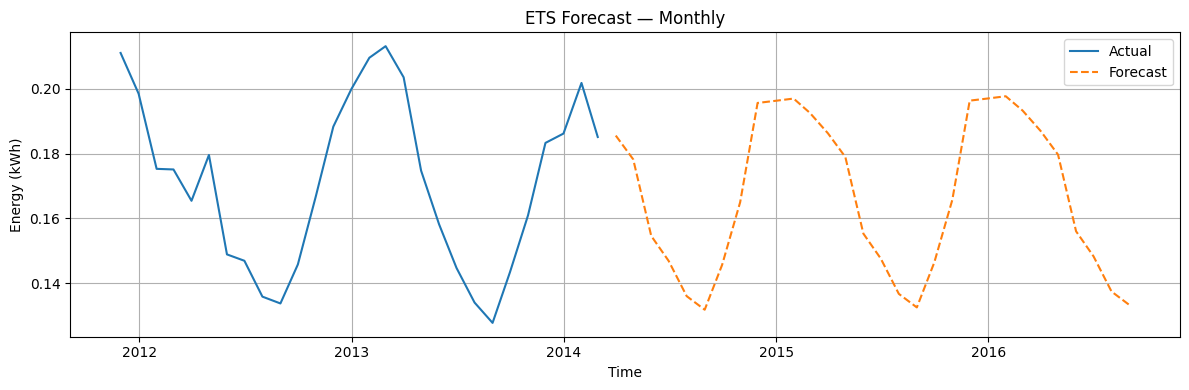

2014-03-31    0.185562
2014-04-30    0.178241
2014-05-31    0.154620
2014-06-30    0.146902
2014-07-31    0.136041
2014-08-31    0.131853
2014-09-30    0.145706
2014-10-31    0.164998
2014-11-30    0.195630
2014-12-31    0.196289
2015-01-31    0.196980
2015-02-28    0.192561
2015-03-31    0.186273
2015-04-30    0.178953
2015-05-31    0.155332
2015-06-30    0.147613
2015-07-31    0.136753
2015-08-31    0.132565
2015-09-30    0.146418
2015-10-31    0.165709
2015-11-30    0.196341
2015-12-31    0.197000
2016-01-31    0.197691
2016-02-29    0.193273
2016-03-31    0.186985
2016-04-30    0.179664
2016-05-31    0.156043
2016-06-30    0.148325
2016-07-31    0.137464
2016-08-31    0.133276
Freq: ME, Name: simulation, dtype: float64

In [5]:
# Forecast using ETS for different time series
def forecast_ets(ts_data, title, seasonal_periods, steps=30):
    model = ETSModel(ts_data, trend='add', seasonal='add', seasonal_periods=seasonal_periods)
    fit = model.fit()
    forecast = fit.forecast(steps)

    plt.figure(figsize=(12, 4))
    plt.plot(ts_data[-90:], label='Actual')
    plt.plot(forecast, label='Forecast', linestyle='--')
    plt.title(f"ETS Forecast — {title}")
    plt.xlabel('Time')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return forecast
# Forecast for different time series
forecast_ets(ts_daily, "Daily", seasonal_periods=7)
forecast_ets(ts_weekly, "Weekly", seasonal_periods=52)
forecast_ets(ts_monthly, "Monthly", seasonal_periods=12)


## Stationarity Summary

- **Hourly:** Not stationary (strong seasonality and trend)
- **Daily:** Slight trend, not stationarity
- **Weekly:** Trend smoothed out more — borderline stationarity
- **Monthly:** Clearly non-stationary

ADF test confirms that higher aggregation tends to produce more stationary series. Hourly data captures volatility, but may not be ideal for forecasting.


## ETS Forecasting Comments

- ETS models adapt well to seasonality (e.g., weekly/daily).
- Monthly forecasts showed growing error margins due to long-term trend.
- Weekly ETS is most balanced: enough data + reasonable granularity.


## Final Takeaways

- Stationarity tests show that energy data at lower precision (monthly) is more stable but less granular.
- ETS models perform best on **weekly data**, especially with consistent seasonality.

Next Steps in future Labs:

- Try ARIMA or Prophet models with exogenous weather variables
- Perform feature engineering for calendar events or holidays
